## KNN -> K-Nearest Neighbors

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [3]:
df=sns.load_dataset("titanic")

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

<Axes: xlabel='age', ylabel='Count'>

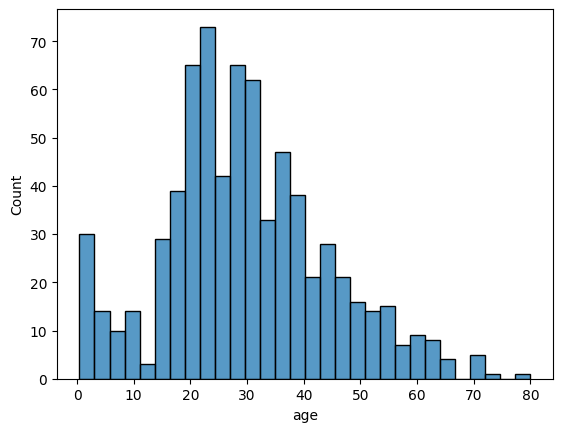

In [8]:
sns.histplot(data=df,x="age",bins=30)

<Axes: xlabel='sex', ylabel='count'>

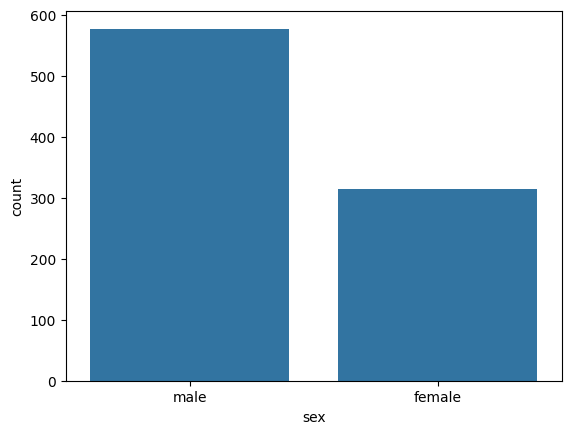

In [9]:
sns.countplot(data=df,x="sex")

<Axes: xlabel='survived', ylabel='count'>

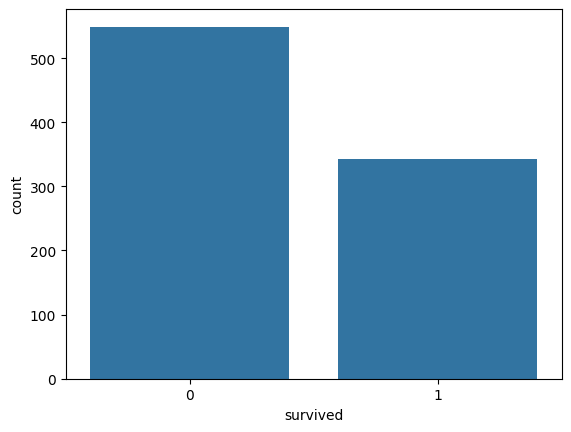

In [10]:
sns.countplot(data=df,x="survived")


<Axes: xlabel='adult_male', ylabel='count'>

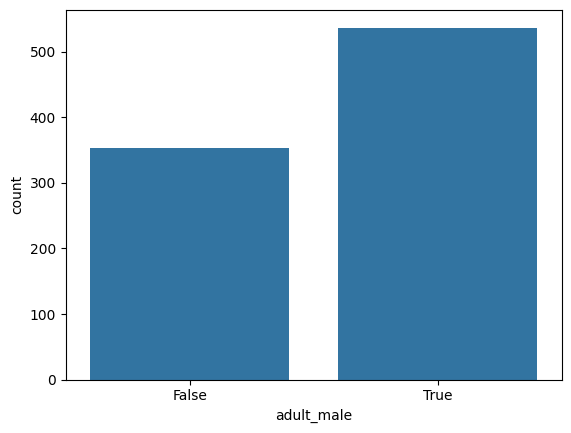

In [11]:
sns.countplot(data=df,x="adult_male")

In [14]:
# data preprocessing
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.drop(['deck','who','alive','parch' ], inplace=True, axis=1)

In [24]:
df.drop(['alone' ], inplace=True, axis=1)


In [25]:
df.head()

,survived,pclass,sex,age,sibsp,fare,embarked,class,adult_male,embark_town
0,0,3,1,22.0,1,7.2500,2,2,1,2
1,1,1,0,38.0,1,71.2833,0,0,0,0
2,1,3,0,26.0,0,7.9250,2,2,0,2
3,1,1,0,35.0,1,53.1000,2,0,0,2
4,0,3,1,35.0,0,8.0500,2,2,1,2


In [26]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le_columns=['sex', 'embark_town', 'embarked', 'adult_male', 'class']

for col in le_columns:
    df[col]=le.fit_transform(df[col])

In [27]:
df.head()

,survived,pclass,sex,age,sibsp,fare,embarked,class,adult_male,embark_town
0,0,3,1,22.0,1,7.2500,2,2,1,2
1,1,1,0,38.0,1,71.2833,0,0,0,0
2,1,3,0,26.0,0,7.9250,2,2,0,2
3,1,1,0,35.0,1,53.1000,2,0,0,2
4,0,3,1,35.0,0,8.0500,2,2,1,2


In [39]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
fare,0
embarked,0
class,0
adult_male,0
embark_town,0


In [41]:
df=df.fillna(df['age'].mean())

In [42]:
X=df.drop('survived',axis=1)
y=df['survived']
scaler= StandardScaler()
X=scaler.fit_transform(X)


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [44]:
X_train.shape

(712, 9)

In [48]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,y_train)

KNeighborsClassifier()

In [49]:
y_predictions=knn_model.predict(X_test)

In [50]:
acc=accuracy_score(y_test,y_predictions)
print(acc)

0.8044692737430168


In [55]:
knn_model_2=KNeighborsClassifier()


In [53]:
# apply cross validation
from sklearn.model_selection import cross_val_score
cv_scores=cross_val_score(knn_model_2,X,y,cv=5)
print(cv_scores)
print(np.mean(cv_scores))

[0.78212291 0.79213483 0.84269663 0.8258427  0.79213483]
0.8069863787583957


In [63]:
from sklearn.model_selection import GridSearchCV

parameter={
    'n_neighbors': [3,4,5,6],
    'weights':['uniform', 'distance'],
    'algorithm':['auto', 'ball_tree', 'kd_tree', 'brute']
}

In [64]:
grid_search_knn=GridSearchCV(
    knn_model_2,
    param_grid=parameter,
    cv=5,
)

In [69]:
grid_search_knn.fit(X,y)
predict_grid=grid_search_knn.predict(X_test)
grid_search_knn.best_params_


{'algorithm': 'auto', 'n_neighbors': 6, 'weights': 'uniform'}

In [67]:
print(classification_report(y_test,predict_grid))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88       105
           1       0.86      0.76      0.81        74

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179

